<a href="https://colab.research.google.com/github/Divyansh-114/MACHINE_LEARNING_MODELS/blob/main/Plant_Diseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
## applying transfer learning and do the prediction on the plant diseases
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset path:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset path: /kaggle/input/plantvillage-dataset
['plantvillage dataset']


In [ ]:
for root, dirs, files in os.walk(path):
    print(root, " | folders:", len(dirs),
          "| files:", len(files))

/kaggle/input/plantvillage-dataset  | folders: 1 | files: 0
/kaggle/input/plantvillage-dataset/plantvillage dataset  | folders: 3 | files: 0
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented  | folders: 38 | files: 0
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Tomato___Late_blight  | folders: 0 | files: 1909
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Tomato___healthy  | folders: 0 | files: 1591
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Grape___healthy  | folders: 0 | files: 423
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Orange___Haunglongbing_(Citrus_greening)  | folders: 0 | files: 5507
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Soybean___healthy  | folders: 0 | files: 5090
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/Squash___Powdery_mildew  | folders: 0 | files: 1835
/kaggle/input/plantvillage-dataset/plantvillage dataset/segmented/P

In [3]:
import os

print(os.listdir(path))

['plantvillage dataset']


In [4]:
dataset_path = os.path.join(path, "plantvillage dataset", "color")

print(os.listdir(dataset_path)[:10])

['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot']


In [5]:
import os
import numpy as np
import tensorflow as tf

from pathlib import Path
from sklearn.model_selection import train_test_split

# Get class names
class_names = sorted([
    folder.name
    for folder in Path(dataset_path).iterdir()
    if folder.is_dir()
])

print("Classes:", len(class_names))

Classes: 38


In [6]:
image_paths = []
labels = []

valid_extensions = {".jpg", ".jpeg", ".png"}

for label, class_name in enumerate(class_names):

    class_dir = Path(dataset_path) / class_name

    for img_path in class_dir.rglob("*"):

        if img_path.suffix.lower() in valid_extensions:
            image_paths.append(str(img_path))
            labels.append(label)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))

Total images: 54305


In [7]:
# First: 80% train, 20% remaining

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Then: split remaining 20% equally
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 43444
Validation images: 5430
Testing images: 5431


In [41]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
], name="data_augmentation")

In [54]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 64

def load_image(path, label):
    # Read image
    image = tf.io.read_file(path)

    # Decode image
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    # Set shape and resize
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)

    # Convert label to integer
    label = tf.cast(label, tf.int32)

    return image, label


# Training dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

train_ds = train_ds.shuffle(1000)

train_ds = train_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Apply augmentation ONLY to training images
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)


# Validation dataset — no augmentation
val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_ds = val_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)


# Test dataset — no augmentation
test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

test_ds = test_ds.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

In [55]:
for images, labels_batch in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels_batch.shape)

Image batch shape: (64, 224, 224, 3)
Label batch shape: (64,)


In [56]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [57]:
base_model = tf.keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,  ## remove the part after the conv part
    input_shape=(224, 224, 3)
)

base_model.trainable = False ## not traing again the base model

In [58]:
## convolution base summary
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [74]:
## making the model and do the classfication on my dataset
model = Sequential()

## now adding the layer in the model

model.add(base_model)

## applying the flatten layer
model.add(Flatten())

## applying the dense layer
model.add(Dense(64,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.Dropout(0.1))

model.add(Dense(32,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.Dropout(0.3))

model.add(Dense(64,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.Dropout(0.1))

model.add(Dense(32,activation='relu'))
model.add(tf.keras.layers.BatchNormalization())
# model.add(tf.keras.layers.Dropout(0.1))

## applying the output layer

## we have 38 classes so we need the softmax activation function
model.add(Dense(len(class_names),activation='softmax'))

In [75]:
## model summary
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │     4,014,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 38)             │         1,254 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,280,422 (23.96 MB)

 Trainable params: 4,022,054 (15.34 MB)

 Non-trainable params: 2,258,368 (8.61 MB)

In [76]:
## normalize the image to increase the learning
def process(image):
  image = tf.cast(image,tf.float32)
  image = tf.image.resize(image,(224,224))
  image = image/255.0
  return image

In [77]:
## compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.01
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [78]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [79]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 477s 684ms/step - accuracy: 0.6417 - loss: 1.2053 - val_accuracy: 0.4816 - val_loss: 2.4051
Epoch 2/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 458s 674ms/step - accuracy: 0.7770 - loss: 0.7088 - val_accuracy: 0.5667 - val_loss: 1.8310
Epoch 3/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 451s 665ms/step - accuracy: 0.8067 - loss: 0.6037 - val_accuracy: 0.5936 - val_loss: 1.7271
Epoch 4/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 452s 665ms/step - accuracy: 0.8242 - loss: 0.5464 - val_accuracy: 0.6033 - val_loss: 1.5844
Epoch 5/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 448s 660ms/step - accuracy: 0.8357 - loss: 0.5040 - val_accuracy: 0.6608 - val_loss: 1.2610
Epoch 6/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 449s 661ms/step - accuracy: 0.8464 - loss: 0.4716 - val_accuracy: 0.6271 - val_loss: 1.5326
Epoch 7/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 455s 670ms/step - accuracy: 0.8554 - loss: 0.4455 - val_accuracy: 0.6076 - val_loss: 1.6557
Epoch 8/10
679/679 ━━━━━━━━━━━━━━━━━━━━ 446s 657ms/step - accuracy: 0.8595 -

In [80]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.7012 - loss: 1.1605
Test Loss: 1.160481333732605
Test Accuracy: 0.7011600136756897


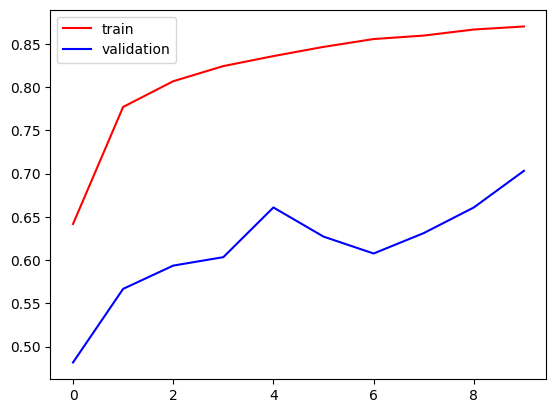

In [81]:
import matplotlib.pyplot as plt


## training and validation accrucay graph
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

## training and validation loss

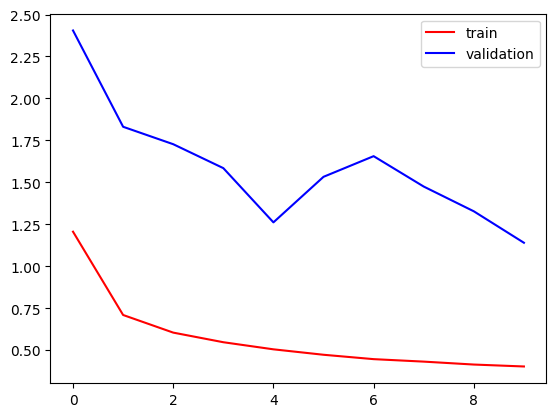

In [82]:
## calculating the loss graph of trainig and validation
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

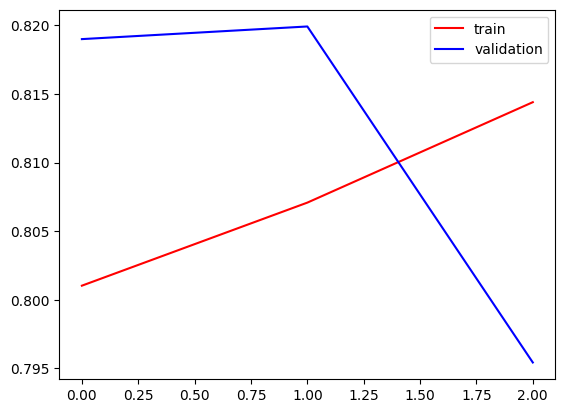

In [29]:
import matplotlib.pyplot as plt


## training and testing  accrucay graph
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

## training and validation loss

In [ ]:
## calculating the loss graph of trainig and testing
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [83]:
### now we will prepare the ouput pipeline for testing on the data

from google.colab import files

uploaded = files.upload()

Saving apple.img to apple (2).img


In [84]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Get the uploaded image filename
image_path = next(iter(uploaded.keys()))

# Load and resize image
img = tf.keras.utils.load_img(
    image_path,
    target_size=(224, 224)
)

# Convert image to array
img_array = tf.keras.utils.img_to_array(img)

# Add batch dimension: (224, 224, 3) -> (1, 224, 224, 3)
img_array = np.expand_dims(img_array, axis=0)

# Apply MobileNetV2 preprocessing
img_array = preprocess_input(img_array)

print("Input shape:", img_array.shape)

Input shape: (1, 224, 224, 3)


In [85]:
# Predict
predictions = model.predict(img_array, verbose=0)

# Get predicted class index
predicted_index = np.argmax(predictions[0])

# Get predicted class name
predicted_class = class_names[predicted_index]

# Get confidence
confidence = predictions[0][predicted_index] * 100

print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2f}%")

Predicted class: Soybean___healthy
Confidence: 74.60%


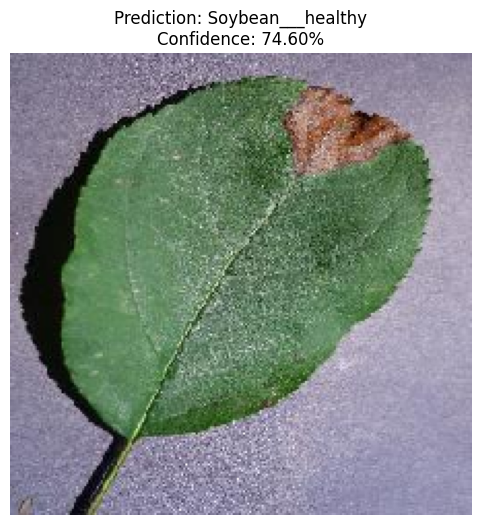

In [86]:
plt.figure(figsize=(6, 6))

plt.imshow(img)
plt.axis("off")

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()

In [87]:
top_3_indices = np.argsort(predictions[0])[-3:][::-1]

for index in top_3_indices:
    print(
        f"{class_names[index]}: "
        f"{predictions[0][index] * 100:.2f}%"
    )

Soybean___healthy: 74.60%
Apple___healthy: 17.51%
Corn_(maize)___Common_rust_: 2.12%
